# Blocking with semantic search in synthetic data
Theodore Charm

- This notebook illustrates how I use semantic search to perform deduplication of a synthetic dataset. It employs sentence transformer (from hugging face) to convert text into numerical vector embeddings, allowing similarity search algorithms to identify and pair potential duplicates in the dataset.

# Introduction
In record deduplication, each record could potentially link to every other record in the same dataset. The number of record pair comparisons has complexity O(n^2), which becomes infeasible to process for large datasets. To reduce computational complexity, record linkage typically involves blocking, which partitions records that share a common set of field attributes, restricting time-consuming matching operations to only these relevant blocks. Traditional blocking approaches group records on exact matching keys, making it struggle with typos or abbreviations. Additionally, if we block on state for example, we fail to identify person entities that moved from one state to another.

This notebook explores a new blocking approach, using semantic search to perform deduplication of a synthetic dataset consisting of 10,000 records, 1,000 of which are duplicates. Semantic search-based blocking group records on actual meaning, allowing it to generate smaller blocks and fewer candidate pairs for record deduplication compared to traditional blocking strategies.

This semantic-based blocking strategy follows the following pipeline:

1. Convert textual records into dense vector embeddings using a pre-trained sentence transformer ("sentence-transformers/all-MiniLM-L6-v2")
2. Calculate the pairwise cosine similarities of the vector representations. Pairs that exceed a specified threshold (e.g. 0.80, 0.90) are grouped into blocks to shrink the search space.
3. Records within the same block are candidate pairs for record deduplication.

This notebook compares the number of candidate pairs and percentage of real duplicate pairs covered for each parameter setting. It examines the following parameters:
- Candidate pairs: Number of record pairs that are within the same block after running the semantic search, ad those pairs are considered potential duplicate pairs, i.e. candidate pairs
- Real duplicates covered: Number of real duplicates that are covered by the candidate pairs obtained by the semantic search
- Duplicates covered (%): Number of real duplicates covered / Number of real duplicates in the dataset * 100%

# Setup
## Packages

In [ ]:
#!pip install sentence_transformers

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Data preprocessing
## Import dataset

In [ ]:
df = pd.read_csv('RLdata10000.csv')
df.head()

,fname_c1,fname_c2,lname_c1,lname_c2,by,bm,bd,rec_id,ent_id
0,FRANK,NaN,MUELLER,NaN,1967,9,27,1,3606
1,MARTIN,NaN,SCHWARZ,NaN,1967,2,17,2,2560
2,HERBERT,NaN,ZIMMERMANN,NaN,1961,11,6,3,3892
3,HANS,NaN,SCHMITT,NaN,1945,8,14,4,329
4,UWE,NaN,KELLER,NaN,2000,7,5,5,1994


## Duplicate record pairs

In [ ]:
# Get a list of real duplicate pairs in the dataset
# ent_id is the true entity id. If two records share the same ent_id, they are true duplicates
def get_duplicate_pairs(df, id_col='ent_id'):
    pairs = []

    # Group by the ID and iterate through the indices
    for _, group in df.groupby(id_col):
        if len(group) > 1:
            # Generate all pairs of indices and ensure index_a < index_b
            for a, b in combinations(group.index, 2):
                if a < b:
                    pairs.append((a, b))
                else:
                    pairs.append((b, a))

    return pairs

In [ ]:
duplicate_list = get_duplicate_pairs(df)
print(f"There are {len(duplicate_list)} true duplicate pairs in the dataset.")

There are 1000 true duplicate pairs in the dataset.


## Serialize the demographic information for each record for semantic search

In [ ]:
# Convert the demographic information to tuples for each person record, then do list comprehension
df['serialized_data'] = [
    f"This person has name {fname} {lname} with year of birth {dob_year}, month of birth {dob_month}, day of birth {dob_day}"
    for fname, lname, dob_year, dob_month, dob_day in zip(df["fname_c1"], df["lname_c1"], df['by'], df['bm'], df['bd'])
]

In [ ]:
df.head()

,fname_c1,fname_c2,lname_c1,lname_c2,by,bm,bd,rec_id,ent_id,serialized_data
0,FRANK,NaN,MUELLER,NaN,1967,9,27,1,3606,This person has name FRANK MUELLER with year o...
1,MARTIN,NaN,SCHWARZ,NaN,1967,2,17,2,2560,This person has name MARTIN SCHWARZ with year ...
2,HERBERT,NaN,ZIMMERMANN,NaN,1961,11,6,3,3892,This person has name HERBERT ZIMMERMANN with y...
3,HANS,NaN,SCHMITT,NaN,1945,8,14,4,329,This person has name HANS SCHMITT with year of...
4,UWE,NaN,KELLER,NaN,2000,7,5,5,1994,This person has name UWE KELLER with year of b...


# Analysis

In [ ]:
# Sentence transformer model
model_name = 'sentence-transformers/all-MiniLM-L6-v2'

In [ ]:
model = SentenceTransformer(model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embeddings = model.encode(df['serialized_data'].to_list(),
                          batch_size=64,
                          show_progress_bar=True,
                          convert_to_numpy=True)     # Keeps memory light

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [ ]:
# Embeddings for each serialized text are represented as numpy arrays
embeddings

array([[-0.07982671,  0.00411688, -0.0694703 , ...,  0.01104881,
         0.00851361, -0.08092476],
       [-0.06341226,  0.04051773, -0.01198603, ..., -0.06977155,
        -0.07733317,  0.01608702],
       [-0.12344594,  0.04085695, -0.07519117, ..., -0.01978136,
        -0.0015788 , -0.04662505],
       ...,
       [-0.03126377,  0.04328609,  0.03028332, ..., -0.06483419,
         0.01476346, -0.05709663],
       [-0.08262878,  0.05258043,  0.00553995, ..., -0.04510354,
         0.04346767, -0.05542538],
       [-0.04215196,  0.03816517, -0.0592616 , ..., -0.04054949,
         0.02017446, -0.02084152]], dtype=float32)

In [ ]:
embeddings.shape

(10000, 384)

In [ ]:
# Compute pairwise cosine similarity for all embeddings
similarity_matrix = cosine_similarity(embeddings)

In [ ]:
np.fill_diagonal(similarity_matrix, 0)  # All diagonal elements are 0
similarity_matrix[np.tril_indices(10000)] = 0  # Set all elements in the lower triangle to 0

# Findings
## Cosine similarity thresholds: Hyperparameter tuning

In [ ]:
similarity_threshold = [0.8, 0.9, 0.95, 0.98]
number_pairs = []
duplicate_covered = []
for threshold in similarity_threshold:
  # Filter pairs with cosine similarity thresholds
  # Get coordinates and values for matches
  row_indices, col_indices = np.where(similarity_matrix >= threshold)
  high_sim_pairs = []

  # List of record pairs examined
  for r, c in zip(row_indices, col_indices):
    high_sim_pairs.append({
        "record_1": r,
        "record_2": c,
        "cosine_similarity": similarity_matrix[r, c]
    })

  # Display candidate pairs with the corresponding similarity scores
  number_pairs.append(len(high_sim_pairs))
  print(f"Total pairs with similarity >= {threshold}: {len(high_sim_pairs)}")

  for pair in high_sim_pairs[:5]:   # Show first 5 matches
    print(f"({pair['record_1']}, {pair['record_2']}): {pair['cosine_similarity']:.4f}")

  # Consider the record pairs as candidate pairs for potential duplicates in the dataset
  candidate_pairs = [(pair['record_1'], pair['record_2']) for pair in high_sim_pairs]
  set1 = set(candidate_pairs)
  total_count = sum(x in set1 for x in duplicate_list)
  percent_duplicate_covered = total_count / len(duplicate_list) * 100    # Percentage of duplicate pairs covered by total pairs examined
  duplicate_covered.append(percent_duplicate_covered)
  print(f"Considering all candidate pairs with similarity score to >={threshold}, they cover {total_count} of the {len(duplicate_list)} duplicate pairs.\n")

Total pairs with similarity >= 0.8: 113925
(0, 689): 0.8735
(0, 1041): 0.8747
(0, 1316): 0.8347
(0, 1695): 0.8688
(0, 1912): 0.8575
Considering all candidate pairs with similarity score to >=0.8, they cover 860 of the 1000 duplicate pairs.

Total pairs with similarity >= 0.9: 5443
(0, 2268): 0.9065
(4, 4040): 0.9463
(4, 4660): 0.9107
(9, 1482): 0.9348
(9, 4945): 0.9279
Considering all candidate pairs with similarity score to >=0.9, they cover 632 of the 1000 duplicate pairs.

Total pairs with similarity >= 0.95: 883
(11, 4268): 0.9610
(16, 3041): 0.9522
(21, 1294): 0.9816
(21, 3007): 0.9601
(21, 4625): 0.9506
Considering all candidate pairs with similarity score to >=0.95, they cover 487 of the 1000 duplicate pairs.

Total pairs with similarity >= 0.98: 280
(21, 1294): 0.9816
(54, 2979): 0.9860
(73, 1404): 0.9888
(85, 4994): 0.9908
(116, 2966): 0.9814
Considering all candidate pairs with similarity score to >=0.98, they cover 260 of the 1000 duplicate pairs.



In [ ]:
# Sample a few similar record pairs, setting the similarity threshold as 0.95
df.loc[[11, 4268, 16, 3041, 21, 1294]]

,fname_c1,fname_c2,lname_c1,lname_c2,by,bm,bd,rec_id,ent_id,serialized_data
11,STEFAN,NaN,RICHTER,NaN,1943,3,22,12,3146,This person has name STEFAN RICHTER with year ...
4268,STEFAN,NaN,RICHTER,NaN,1946,3,22,4269,3146,This person has name STEFAN RICHTER with year ...
16,KURT,NaN,MUELLER,NaN,1966,9,12,17,223,This person has name KURT MUELLER with year of...
3041,KURT,NaN,MUELLER,NaN,1963,7,21,3042,3704,This person has name KURT MUELLER with year of...
21,GUENTHER,NaN,MUELLER,NaN,1994,11,17,22,1926,This person has name GUENTHER MUELLER with yea...
1294,GUENTHER,NaN,MUELLER,NaN,1993,11,19,1295,2510,This person has name GUENTHER MUELLER with yea...


(11,4268), (16,3041), (21,1294) are candidate pairs for duplicates, though only (11,4268) is a true duplicate pair.

In [ ]:
# Create dataframe
data = {
    'threshold': ['0.80', '0.90', '0.95', '0.98'],
    'candidate_pairs': number_pairs,
    'duplicate_covered (%)': duplicate_covered
}
plot_threshold = pd.DataFrame(data)

## Data visualization

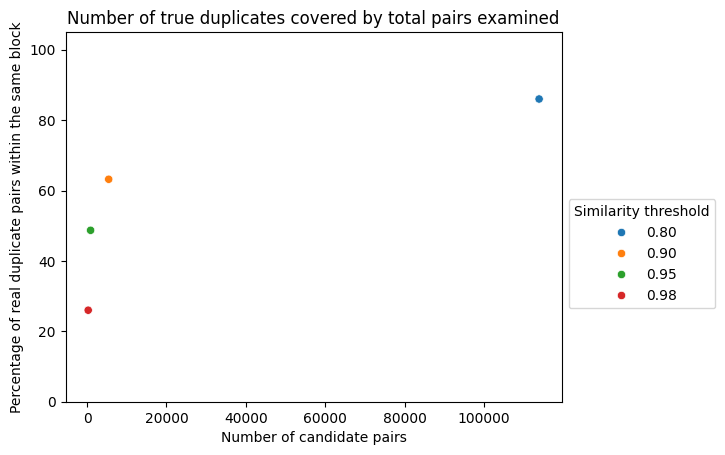

In [ ]:
# Scatter plot of % true duplicates covered against # candidate pairs
ax = sns.scatterplot(x='candidate_pairs', y='duplicate_covered (%)', hue='threshold', data=plot_threshold)
ax.set(title = "Number of true duplicates covered by total pairs examined", ylim=(0,105))
ax.legend(loc='center left', bbox_to_anchor=(1, 0.4), ncol=1, title = "Similarity threshold")
plt.xlabel("Number of candidate pairs")
plt.ylabel("Percentage of real duplicate pairs within the same block")
plt.show()

## Interpretation
This scatter plot illustrates that the number and percentage of real duplicates covered are driven by the cosine similarity threshold. If we decrease the similarity threshold, we can include more candidate pairs. This can increase the number and percentage of true duplicates covered.

# Conclusions
- Semantic search can compute blocks covering real duplicate pairs in large datasets
- Semantic search-based blocks are small relative to traditional blocking approaches, potentially increasing efficiency of downstream record linkage processes
- There is a trade-off between the number of candidate pairs and number of true duplicates covered. Decreasing the similarity threshold can increase the number and percentage of real duplicates covered, but it also increases the number of candidate pairs. This increases the computational complexity exponentially.